# Set-up

In [1]:
# Import packages
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from torch.utils.data import DataLoader, Subset
import os, sys, json, time, glob, warnings
from torchmetrics.functional import structural_similarity_index_measure as ssim


# Add parent directory to sys.path for module imports
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Import modules
from src.data.dataset import LidarS2Dataset
from src.data.processing import compute_s2_mean_std_multi
from src.model.unet import ConditionalUNet
from src.diffusion.scheduler import LinearDiffusionScheduler, CosineDiffusionScheduler
from src.diffusion.sampling import p_sample_loop_ddpm, p_sample_loop_ddim, p_sample_loop_plms
from src.utils.metrics import compute_topographic_rmse, normalize_batch
import rasterio
from scripts.main import run_reconstruction_evaluation
from src.data.dataset import LidarS2Dataset
from src.utils.recon_metrics import (
    rmse as rmse_recon,
    bias as bias_recon,
    sigma_error,
    corr_length_error,
    normal_angle_error,
    average_jsd_multiscale,
    log_psd_rmse,
    agg
)

# Ignore warnings
warnings.filterwarnings("ignore")

/cs/student/projects2/aisd/2024/tcannon/dissertation/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Trained Model

In [2]:
# Config 

CKPT_PATH = "/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/models/og_final_model_k6_att_best.pth"         
TEST_S2_DIR = ["/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/input_data/s2_patches_pondinlet",
               "/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/input_data/s2_patches_tuk"]
TEST_LIDAR_DIR = ["/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/input_data/lidar_patches_pondinlet",
                  "/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/input_data/lidar_patches_tuk"]
OUT_DIR = "/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/figures/test"

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"
ckpt = torch.load(CKPT_PATH, map_location=device)
config = ckpt["config"]  # original training config

# Override paths for test data
config["data"]["s2_dir"]   = TEST_S2_DIR
config["data"]["lidar_dir"] = TEST_LIDAR_DIR
config["logging"]["output_dir"] = OUT_DIR
config["system"]["device"] = device

In [3]:
# Create test dataset 

test_dataset = LidarS2Dataset(
    lidar_dirs=TEST_LIDAR_DIR,
    s2_dirs=TEST_S2_DIR,
    context_k=config["training"]["context_k"],
    randomize_context=False,
    augment=False,
    debug=False,
    split="val"  
)

Prepared 12873 matched LiDAR↔S2 groups (k=6).


In [4]:
# Load in trained model

model = ConditionalUNet(
    in_channels=1,
    cond_channels=4 * config["training"]["context_k"],
    attr_dim=8 * config["training"]["context_k"],
    base_channels=config["model"]["base_channels"],
    embed_dim=config["model"]["embed_dim"],
    unet_depth=config["model"]["unet_depth"],
    attention_variant=config["model"]["attention_variant"],
    cond_k=config["training"]["context_k"]
).to(device)
model.load_state_dict(ckpt["model_state_dict"])

# Load in diffusion scheduler from trained model
if config["training"]["noise_schedule"] == "linear":
    scheduler = LinearDiffusionScheduler(config["training"]["timesteps"], device=device)
else:
    scheduler = CosineDiffusionScheduler(config["training"]["timesteps"], device=device)


# Inference

In [22]:
def run_inference(model, val_dataset, config, scheduler=None,out_path=None):
    """
    Run inference using trained model. 
    """
    print("\n" + "="*60)
    print("RUNNING RECONSTRUCTION EVALUATION")
    print("="*60)

    # Set random seed for reproducibility
    torch.manual_seed(config["system"].get("seed", 42))

    # Set split for augmentation control
    val_dataset.split = "val"

    # Define output directories
    output_dir = config["logging"]["output_dir"]
    stats_dir = os.path.join(output_dir, "reconstruction_statistics")
    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(stats_dir, exist_ok=True)
    
    # Set model to eval
    model.eval()
    
    # Access hand-picked validation sets by ID
    #eval_pids = ["00010", "00025", "00050", "00060", "00100", "00150", "00008", "00009"] tuq eval
    #eval_pids = ["05517", "05516", "05604", "05901", "05919", "05927", "05975", "05851"]  # cambridge eval
    #eval_pids = ["05604", "05516", "05851", "05919"]  # cambridge eval
    #eval_pids = ["01851", "01924","05510","05511"]

    # new data
    #eval_pids = ["05275","05301", "05400", "05408"] # pond inlet
    eval_pids = ["12518","12524","12544","12551"]

    # Find the indices of these patches in the validation dataset
    eval_indices = [i for i, sample in enumerate(val_dataset.samples) if sample['tile_id'] in eval_pids]

    # Handle the case where not all patches are found
    if len(eval_indices) != len(eval_pids):
        print(f"Warning: Found {len(eval_indices)} out of 8 requested evaluation patches. Continuing with found patches.")
    
    # Create a Subset of the validation dataset using the found indices
    eval_subset = Subset(val_dataset, eval_indices)

    # Create eval loader
    eval_loader = DataLoader(eval_subset, batch_size=len(eval_subset), shuffle=False)
    
    # Access the single batch from the evaluation loader
    batch = next(iter(eval_loader))
    s2 = batch["s2"].to(config["system"]["device"])
    lidar = batch["lidar"].to(config["system"]["device"])
    attrs = batch["attrs"].to(config["system"]["device"])
    mask = batch["mask"].to(config["system"]["device"])
    chosen_ids_batch = batch["chosen_ids"]
    tile_ids_batch = batch["tile_id"] 

    # Get batch dimensions and context information
    B = lidar.size(0)
    context_k = config["training"]["context_k"]
    run_name = config["logging"]["run_name"]

    # Get sampling methods
    all_samplers = {
        "ddpm": lambda m, s, c, a, d: p_sample_loop_ddpm(m, scheduler, s, c, a, d) if scheduler else None,
        "ddim": lambda m, s, c, a, d: p_sample_loop_ddim(m, scheduler, s, c, a, d) if scheduler else None,
        "plms": lambda m, s, c, a, d: p_sample_loop_plms(m, scheduler, s, c, a, d) if scheduler else None,
    }
    requested_methods = config["evaluation"]["sampling_methods"]
    p_samplers = {m: all_samplers[m] for m in requested_methods if m in all_samplers}
    if not p_samplers:
        print("No valid samplers available")
        return

    # Determine which sentinel-2 patches were used to condition the model
    used_patch_ids = chosen_ids_batch

    # Iterate over each sampling method
    for sampler_name, sampler_func in p_samplers.items():
        print(f"\nSampling method: {sampler_name}")

        # Sample from the model
        with torch.no_grad():
            torch.cuda.synchronize()
            start_time = time.perf_counter()
            pred = sampler_func(model, lidar.shape, s2, attrs, config["system"]["device"])
            pm = batch["lidar_patch_mean"].to(config["system"]["device"]).view(-1, 1, 1, 1)
            pred = pred + pm
            lidar_phys = lidar + pm
            gt = lidar_phys.cpu()
            pred = pred.cpu()
            m = mask.cpu() if mask is not None else None
            torch.cuda.synchronize()
            end_time = time.perf_counter()
            sampling_time = end_time - start_time

            # Get metric parameters from config
            px = float(config["data"].get("pixel_size_m", 1.0))
            jsd_scales = tuple(config["evaluation"].get("jsd_scales_m", [1.0, 2.0, 5.0, 10.0]))
            jsd_bins   = int(config["evaluation"].get("jsd_bins", 256))
            use_sobel  = bool(config["evaluation"].get("nae_use_sobel", True))
            deg        = bool(config["evaluation"].get("nae_degrees", True))
            use_window = bool(config["evaluation"].get("psd_window", True))

            # Calculate and log core reconstruction metrics for the entire batch
            rmse_tile, bias_tile, sigma_tile_pct = [], [], []
            clen_tile_pct, nae_tile, jsd_tile, psd_tile = [], [], [], []
            valid_counts = []
            for i in range(B):
                # Get data for each tile
                gi, pi = gt[i], pred[i]

                # Get mask
                mm = m[i] if m is not None else None
                valid_counts.append(int(mm.sum()))
                mm = mm.bool() if mm is not None else None
                
                # Calculate metrics
                rmse_tile.append(rmse_recon(gi, pi, mask=mm).item())
                bias_tile.append(bias_recon(gi, pi, mask=mm).item())
                sigma_tile_pct.append(sigma_error(gi, pi, mask=mm).item())
                clen_tile_pct.append(corr_length_error(gi, pi, mask=mm, pixel_size=px).item())
                nae_tile.append(normal_angle_error(gi, pi, mask=mm, pixel_size=px, use_sobel=use_sobel, degrees=deg).item())
                jsd_tile.append(average_jsd_multiscale(gi, pi, scales_m=jsd_scales, pixel_size=px, bins=jsd_bins, mask=mm).item())
                psd_tile.append(log_psd_rmse(gi, pi, pixel_size=px, mask=mm, window=use_window).item())
                
                # Save reconstruction statistics for each sample
                tile_id = tile_ids_batch[i]
                reco_stats = {
                    "tile_id": tile_id,
                    "rmse_phys_m": rmse_tile[i],
                    "bias_phys_m": bias_tile[i],
                    "sigma_error_pct": sigma_tile_pct[i],
                    "corr_length_error_pct": clen_tile_pct[i],
                    "normal_angle_error_deg": nae_tile[i],
                    "jsd": jsd_tile[i],
                    "psd_rmse": psd_tile[i],
                    "valid_pixel_count": valid_counts[i],
                    "gt_min_val": float(gt[i].min()),
                    "gt_max_val": float(gt[i].max()),
                    "gt_mean_val": float(gt[i].mean()),
                    "gt_std_val": float(gt[i].std()),
                    "pred_min_val": float(pred[i].min()),
                    "pred_max_val": float(pred[i].max()),
                    "pred_mean_val": float(pred[i].mean()),
                    "pred_std_val": float(pred[i].std()),
                    "gt_mode_val": float(torch.mode(gt[i].flatten().to(torch.float32))[0]),
                    "pred_mode_val": float(torch.mode(pred[i].flatten().to(torch.float32))[0]),
                }
                
                debug_flag = "_debug_" if config["system"]["debug"] else ""
                #stats_path = os.path.join(stats_dir, f"{tile_id}{debug_flag}{run_name}_{sampler_name}_stats.json")
                #with open(stats_path, "w") as f:
                    #json.dump(reco_stats, f, indent=4)
                #print(f"Saved stats for tile {tile_id} to {stats_path}")

            # Calculate averages for logging
            rmse_mean   = agg(rmse_tile, weights=valid_counts, reduce="weighted")  # micro-average
            bias_mean   = agg(bias_tile, weights=valid_counts, reduce="weighted")
            sigma_mean  = agg(sigma_tile_pct, reduce="mean")     # macro-average
            sigma_med   = agg(sigma_tile_pct, reduce="median")   # robustness
            ell_mean    = agg(clen_tile_pct, reduce="mean")
            ell_med     = agg(clen_tile_pct, reduce="median")
            nae_mean    = agg(nae_tile, weights=valid_counts, reduce="weighted")
            jsd_mean    = agg(jsd_tile, reduce="mean")
            psd_mean    = agg(psd_tile, reduce="mean")
            
            # Determine the total number of rows (S2 patches + GT + Pred + Error)
            num_s2_patches = 2 # Assuming context_k is the number of S2 patches
            num_data_rows = 3 # GT, Pred, Error
            total_rows = num_s2_patches + num_data_rows 
            num_cols = B # Number of examples

            # Calculate figure size (adjust these constants based on desired output size)
            tile_size_inches = 6
            # fig_w: columns * size. We need extra width for the left-side text labels.
            fig_w = num_cols * tile_size_inches + 2 
            fig_h = total_rows * tile_size_inches + 1 # Add space for footer/labels
            
            # Create a figure and grid of subplots
            fig, axes = plt.subplots(total_rows, num_cols, 
                                     figsize=(fig_w, fig_h), 
                                     squeeze=False, # Ensure axes is 2D array even for 1xN
                                     gridspec_kw={'hspace': 0.05, 'wspace': 0.05}) 
            
            # Determine global elevation and error ranges for consistent colormapping
            global_elev_min = torch.min(gt.min(), pred.min()).item()
            global_elev_max = torch.max(gt.max(), pred.max()).item()
            signed_error = gt.squeeze(1) - pred.squeeze(1) 
            max_abs_error = signed_error.abs().max().item()

            # Process S2 patches for visualization 
            tileid_to_s2dir = {s['tile_id']: s['s2_group_dir'] for s in val_dataset.samples}
            s2_viz_data = [] 
            for i in range(B):
                tile_id = tile_ids_batch[i]
                s2_group_dir = tileid_to_s2dir.get(tile_id)
                if s2_group_dir is None:
                    print(f"Warning: no s2_group_dir found for tile {tile_id}; skipping S2 viz.")
                    s2_viz_data.append([np.zeros((*gt.shape[-2:], 3), dtype=np.float32) for _ in range(context_k)])
                    continue
                chosen_ids = chosen_ids_batch[i].tolist()
                
                processed_sample = []
                for t_id in chosen_ids:
                    s2_path = os.path.join(s2_group_dir, f"t{t_id}.tif")
                    with rasterio.open(s2_path) as src:
                        arr = torch.from_numpy(src.read()[:4].astype(np.float32))
                    
                    rgb = arr[[0, 1, 2], :, :]
                    rgb = normalize_batch(rgb.unsqueeze(0)).squeeze(0)
                    rgb = F.interpolate(rgb.unsqueeze(0), size=gt.shape[-2:], mode="bilinear", align_corners=False).squeeze(0)
                    processed_sample.append(rgb.permute(1, 2, 0).numpy()) # Convert to HxWx3 NumPy
                s2_viz_data.append(processed_sample)

            # Set row titles
            row_titles = ["S2 Sample #1", "S2 Sample #2", "GT LiDAR", "Pred LiDAR", "Error"]
        
            # Iterate over examples (columns)
            for col in range(num_cols): 
                # Data for the current example 
                gt_i = gt[col].squeeze().numpy()
                pred_i = pred[col].squeeze().numpy()
                err_i = (gt[col].squeeze() - pred[col].squeeze()).numpy()
                
                # S2 Patches 
                for row in range(num_s2_patches):
                    ax = axes[row, col]
                    s2_np = s2_viz_data[col][row]
                    
                    ax.imshow(s2_np) 
                    ax.axis("off")

                # Lidar GT
                row_gt = num_s2_patches
                ax = axes[row_gt, col]
                im_gt = ax.imshow(gt_i, cmap='terrain', vmin=global_elev_min, vmax=global_elev_max)
                ax.axis("off")
               

                # Lidar Pred
                row_pred = num_s2_patches + 1
                ax = axes[row_pred, col]
                im_pred = ax.imshow(pred_i, cmap='terrain', vmin=global_elev_min, vmax=global_elev_max)
                ax.axis("off")

                # Error Map
                row_err = num_s2_patches + 2
                ax = axes[row_err, col]
                # Define the linear scale around zero 
                linthresh_val = 0.5
                # Create a symmetric logarithmic normalizer
                norm_error = mcolors.SymLogNorm(
                    linthresh=linthresh_val, 
                    linscale=1.0, # Linear scale for linthresh region
                    vmin=-max_abs_error, 
                    vmax=max_abs_error
                )
                im_err = ax.imshow(err_i, cmap='seismic',norm=norm_error)
                ax.axis("off")
            
            # Set row titles
            for row in range(total_rows):
                ax = axes[row, 0] 
                ax.text(-0.1, 0.5, row_titles[row], 
                        ha="right", va="center", 
                        transform=ax.transAxes, 
                        fontsize=20, 
                        fontweight='bold', 
                        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.3'))

            # Set footer
            footer = (f"RMSE: {rmse_mean:.2f} m  |  Bias: {bias_mean:.2f} m  |  Δσ: {sigma_mean:.2f} %  |  Δℓ: {ell_mean:.2f} %  |  NAE: {nae_mean:.2f}°  |  JSD: {jsd_mean:.2f}  |  PSD: {psd_mean:.2f}")
            fig.text(0.5, 0.01, footer, ha='center', fontsize=23, weight='bold', color='darkblue')

            # Identify the axes in the last column to anchor color bars
            ax_gt_anchor = axes[row_gt, num_cols - 1]
            ax_err_anchor = axes[row_err, num_cols - 1]

            # GT / Pred Colorbar 
            axins_gt = inset_axes(ax_gt_anchor, 
                                  width="5%", 
                                  height="205%", 
                                  loc='right', 
                                  bbox_to_anchor=(0.1, -0.52, 1, 1),
                                  bbox_transform=ax_gt_anchor.transAxes)
            fig.colorbar(im_gt, cax=axins_gt)

            # Error Colorbar
            axins_err = inset_axes(ax_err_anchor, 
                                   width="5%", 
                                   height="100%", 
                                   loc='right', 
                                   bbox_to_anchor=(0.1, 0, 1, 1), 
                                   bbox_transform=ax_err_anchor.transAxes)
            fig.colorbar(im_err, cax=axins_err)

            # Adjust layout
            plt.subplots_adjust(left=0.08, bottom=0.08, top=0.98, right=0.95)
            
            # Show figure
            plt.show()
            
            # Save the figure
            fig.savefig(out_path, dpi=300, bbox_inches='tight')
            plt.close()

            print(f"Saved visualization to {out_path}")


RUNNING RECONSTRUCTION EVALUATION

Sampling method: plms


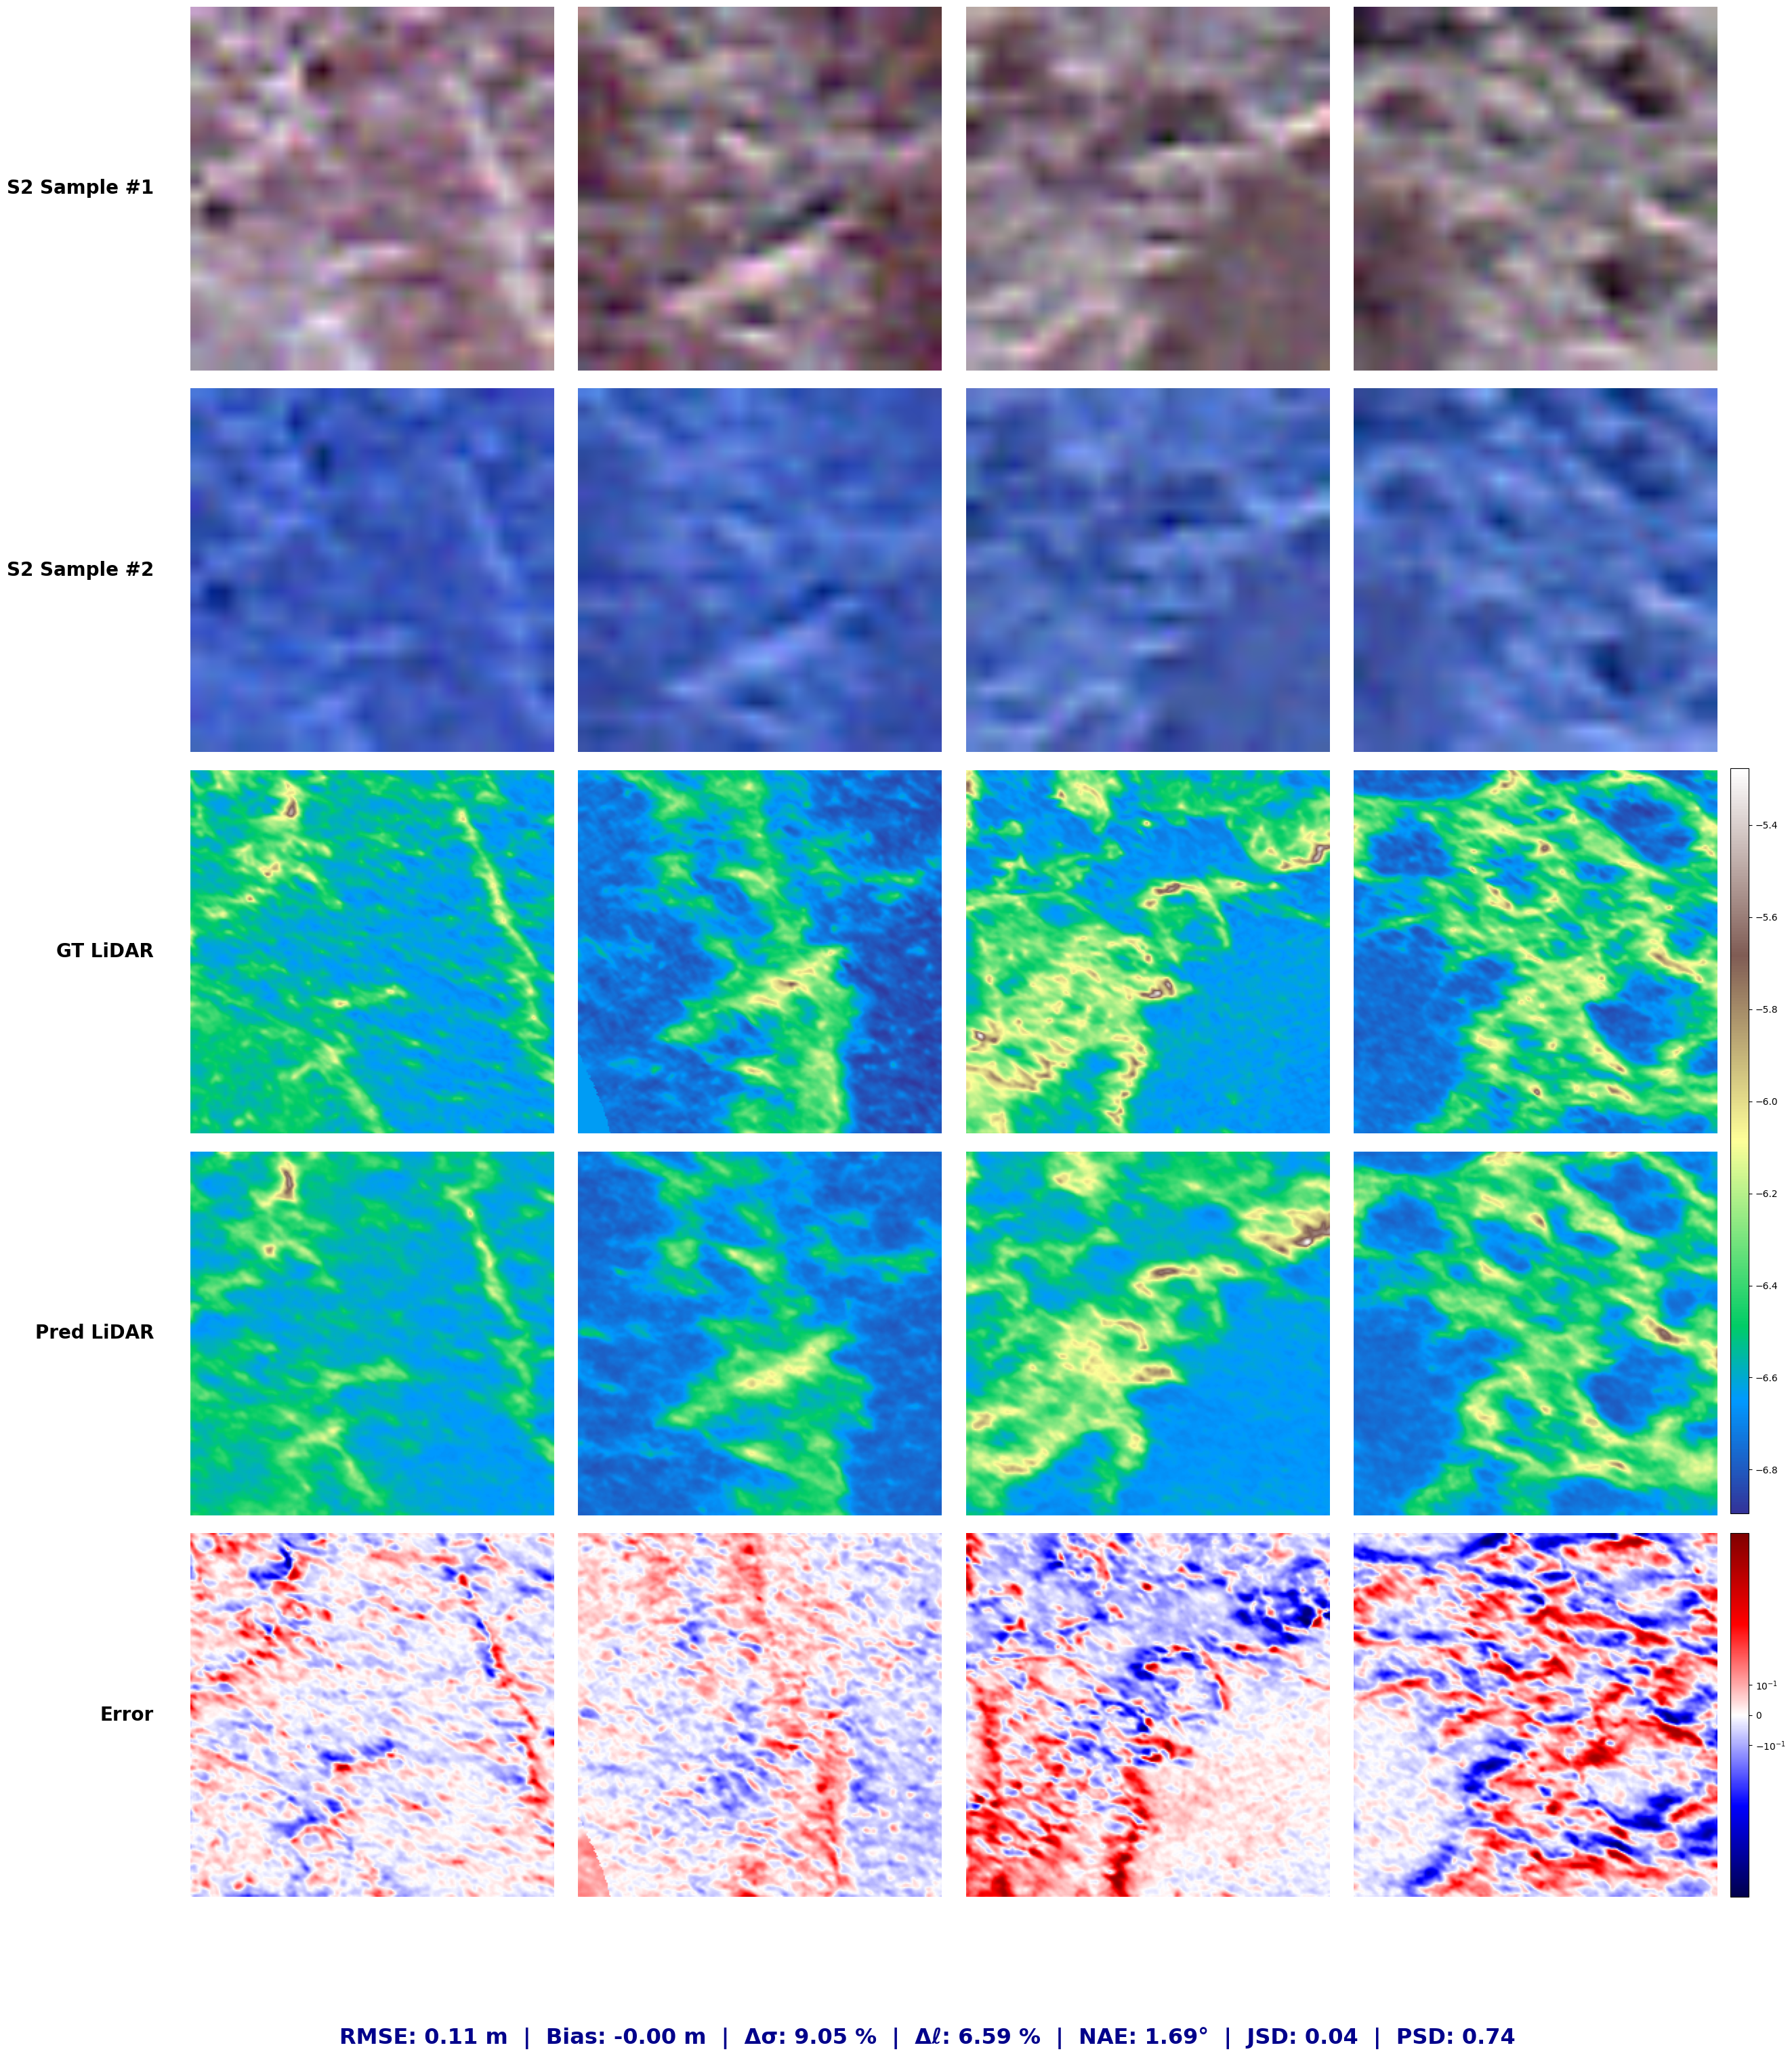

Saved visualization to /cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/figures/final_val_recontruction.png


In [23]:
# Run inference

run_inference(model, test_dataset, config, scheduler=scheduler, out_path='/cs/student/projects2/aisd/2024/tcannon/dissertation/Dissertation/figures/final_val_recontruction.png')